# A06 — PyTorch Vanilla RNN dự báo giá đóng cửa AAPL

Notebook này huấn luyện đúng một mô hình **Vanilla RNN** cho bài toán đã khóa:

$$
\underbrace{30\ \text{ngày giao dịch trước} \times 5\ \text{đặc trưng}}_{X}
\longrightarrow
\underbrace{\text{Close của ngày giao dịch kế tiếp}}_{y}.
$$

Chỉ các artifact đã hoàn tất ở bước tiền xử lý chung được sử dụng. Notebook không đọc lại CSV gốc, không tạo split mới, không fit scaler và không dùng TEST để chọn mô hình. Đây là thực hành kỹ thuật, **không phải khuyến nghị tài chính**.


## 1. Thiết lập tái lập và đường dẫn

`SEED = 42` được áp dụng cho Python, NumPy và PyTorch. Môi trường hiện tại chỉ có CPU; cấu hình nhỏ giúp notebook chạy nhanh và dễ kiểm tra. Các thư mục output được tạo nếu chưa có, nhưng dữ liệu đầu vào chỉ được đọc.


In [ ]:
from pathlib import Path
import hashlib
import json
import random
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.pytorch_stock import (
    StockRNN,
    StockSequenceDataset,
    count_trainable_parameters,
    inverse_transform_targets,
    predict_scaled_targets,
    regression_metrics,
    train_with_early_stopping,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.use_deterministic_algorithms(True)
torch.set_num_threads(1)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PROCESSED_DIR = ROOT / "datasets" / "processed"
METADATA_PATH = ROOT / "results" / "metrics" / "preprocessing_metadata.json"
CHECKPOINT_PATH = ROOT / "models" / "pytorch" / "pytorch_stock_rnn_best.pt"
METRICS_PATH = ROOT / "results" / "metrics" / "pytorch_stock_metrics.json"
PREDICTIONS_PATH = ROOT / "results" / "predictions" / "pytorch_stock_predictions.csv"
FIGURE_DIR = ROOT / "results" / "figures" / "pytorch_stock"

for directory in (
    CHECKPOINT_PATH.parent,
    METRICS_PATH.parent,
    PREDICTIONS_PATH.parent,
    FIGURE_DIR,
):
    directory.mkdir(parents=True, exist_ok=True)

print(f"Project root: {ROOT}")
print(f"PyTorch: {torch.__version__} | device: {DEVICE} | seed: {SEED}")

Project root: C:\DATA\assign\A06
PyTorch: 2.14.0+cpu | device: cpu | seed: 42


## 2. Nạp đúng artifact đã khóa

Mỗi NPZ phải có `X`, `y`, `y_scaled`, `target_date` và `naive_last_close`. Notebook đối chiếu SHA-256 với `preprocessing_metadata.json`, kiểm tra shape `(samples, 30, 5)`, ngày tăng nghiêm ngặt trong từng split và thứ tự thời gian `TRAIN < validation < TEST`.

Năm đặc trưng theo đúng thứ tự là `Open`, `High`, `Low`, `Close`, `Volume`. `target_date` chỉ là metadata để truy vết và vẽ biểu đồ; nó không đi vào mô hình.


In [2]:
def sha256(path: Path) -> str:
    return hashlib.sha256(path.read_bytes()).hexdigest()


metadata = json.loads(METADATA_PATH.read_text(encoding="utf-8"))
stock_meta = metadata["stock"]
assert metadata["seed"] == SEED
assert stock_meta["sequence_length"] == 30
assert stock_meta["feature_names"] == ["Open", "High", "Low", "Close", "Volume"]

artifacts = {}
artifact_hashes = {}
required_keys = {"X", "y", "y_scaled", "target_date", "naive_last_close"}

for split in ("train", "val", "test"):
    info = stock_meta["artifacts"][split]
    path = ROOT / info["path"]
    actual_hash = sha256(path)
    assert actual_hash == info["sha256"], f"Checksum sai: {path}"
    with np.load(path) as loaded:
        assert set(loaded.files) == required_keys
        artifacts[split] = {name: loaded[name].copy() for name in loaded.files}
    data = artifacts[split]
    assert data["X"].shape[1:] == (30, 5)
    assert data["y"].shape == data["y_scaled"].shape == data["target_date"].shape
    assert len(data["X"]) == len(data["y"])
    assert np.isfinite(data["X"]).all()
    assert np.isfinite(data["y"]).all()
    assert np.isfinite(data["y_scaled"]).all()
    assert np.all(data["target_date"][1:] > data["target_date"][:-1])
    artifact_hashes[split] = actual_hash

assert artifacts["train"]["target_date"][-1] < artifacts["val"]["target_date"][0]
assert artifacts["val"]["target_date"][-1] < artifacts["test"]["target_date"][0]

split_summary = pd.DataFrame(
    [
        {
            "split": split.upper(),
            "X shape": str(data["X"].shape),
            "y shape": str(data["y"].shape),
            "ngày đầu": str(data["target_date"][0]),
            "ngày cuối": str(data["target_date"][-1]),
        }
        for split, data in artifacts.items()
    ]
)
split_summary

,split,X shape,y shape,ngày đầu,ngày cuối
0,TRAIN,"(1915, 30, 5)","(1915,)",2015-02-17,2022-09-22
1,VAL,"(411, 30, 5)","(411,)",2022-09-23,2024-05-13
2,TEST,"(410, 30, 5)","(410,)",2024-05-14,2025-12-31


## 3. Regression, target scaling và đơn vị đánh giá

Đây là **regression** vì đầu ra là một giá trị liên tục (giá `Close`), khác classification vốn dự đoán nhãn rời rạc. Pipeline chung đã chuẩn hóa cả đầu vào và target bằng thống kê từ **chỉ TRAIN**. Mô hình học `y_scaled`; vì vậy `MSELoss` trong quá trình huấn luyện nằm trong **không gian chuẩn hóa**, không phải USD².

Sau khi chọn checkpoint bằng validation loss, dự đoán TEST sẽ được `inverse_transform` bằng target scaler đã khóa. Chỉ khi đó MAE và RMSE mới có đơn vị USD. Không được fit lại scaler trên validation hay TEST.


In [3]:
target_scaler_info = stock_meta["target_scaler"]
target_scaler_path = ROOT / target_scaler_info["path"]
assert sha256(target_scaler_path) == target_scaler_info["sha256"]
target_scaler = joblib.load(target_scaler_path)
assert int(target_scaler.n_samples_seen_) == len(artifacts["train"]["y"])

for split, data in artifacts.items():
    restored = inverse_transform_targets(target_scaler, data["y_scaled"])
    np.testing.assert_allclose(restored, data["y"], rtol=1e-5, atol=1e-4)

print("Target scaler:", type(target_scaler).__name__)
print("Fit scope:", target_scaler_info["fit_scope"])
print(f"TRAIN mean={target_scaler.mean_[0]:.6f}, scale={target_scaler.scale_[0]:.6f}")
print("Inverse-transform khớp raw y ở cả ba split.")

Target scaler: StandardScaler
Fit scope: TRAIN y only
TRAIN mean=71.203423, scale=48.037949
Inverse-transform khớp raw y ở cả ba split.


## 4. Dataset và DataLoader

`StockSequenceDataset` ánh xạ mỗi mẫu thành tensor `X` có shape `(30, 5)` và một target vô hướng đã scale. Khi ghép batch, mô hình nhận `(batch_size, 30, 5)`.

`DataLoader` chia dữ liệu thành mini-batch. Chỉ TRAIN dùng `shuffle=True` để thay đổi thứ tự cập nhật gradient; validation và TEST giữ `shuffle=False`. Việc shuffle các mẫu TRAIN không làm thay đổi thứ tự 30 time step bên trong từng sequence.


In [ ]:
BATCH_SIZE = 64
generator = torch.Generator().manual_seed(SEED)

datasets = {
    split: StockSequenceDataset(data["X"], data["y_scaled"])
    for split, data in artifacts.items()
}
train_loader = DataLoader(
    datasets["train"], batch_size=BATCH_SIZE, shuffle=True, generator=generator
)
validation_loader = DataLoader(datasets["val"], batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(datasets["test"], batch_size=BATCH_SIZE, shuffle=False)

batch_x, batch_y = next(iter(train_loader))
print("Một TRAIN batch:", tuple(batch_x.shape), tuple(batch_y.shape))
print(
    "Số batch TRAIN / validation / TEST:",
    len(train_loader),
    len(validation_loader),
    len(test_loader),
)

Một TRAIN batch: (64, 30, 5) (64,)
Số batch TRAIN / validation / TEST: 30 7 7


## 5. Kiến trúc Vanilla RNN

Với `batch_first=True`, RNN đọc lần lượt 30 vector đặc trưng. Hidden state được cập nhật qua thời gian:

$$h_t = \tanh(W_{xh}x_t + W_{hh}h_{t-1} + b).$$

`h_n[-1]` là hidden state sau ngày thứ 30: một biểu diễn cô đọng của cửa sổ lịch sử. Lớp `Linear(64, 1)` biến biểu diễn này thành một giá trị target đã scale. Không có Sigmoid vì regression không cần ép đầu ra vào `[0, 1]`; mô hình chính cũng không được thay bằng LSTM/GRU.


In [5]:
HIDDEN_SIZE = 64
model = StockRNN(input_size=5, hidden_size=HIDDEN_SIZE, num_layers=1).to(DEVICE)
parameter_count = count_trainable_parameters(model)

with torch.inference_mode():
    demo_output = model(batch_x[:4].to(DEVICE))

print(model)
print("Demo input:", tuple(batch_x[:4].shape), "-> output:", tuple(demo_output.shape))
print("Trainable parameters:", f"{parameter_count:,}")
assert isinstance(model.rnn, nn.RNN)
assert model.rnn.batch_first is True
assert parameter_count == 4609

StockRNN(
  (rnn): RNN(5, 64, batch_first=True)
  (regressor): Linear(in_features=64, out_features=1, bias=True)
)
Demo input: (4, 30, 5) -> output: (4,)
Trainable parameters: 4,609


## 6. Huấn luyện bằng MSE và early stopping

`MSELoss` lấy trung bình bình phương sai số trong không gian target đã scale, nên phạt sai số lớn mạnh hơn sai số nhỏ. Adam cập nhật trọng số từ gradient của TRAIN. Sau mỗi epoch, validation loss được tính mà không cập nhật trọng số.

Checkpoint được ghi khi validation loss đạt mức thấp nhất mới. `patience=5` dừng khi không có cải thiện đủ ý nghĩa trong năm epoch liên tiếp; sau cùng mô hình luôn khôi phục checkpoint có **validation loss thô thấp nhất**. TEST hoàn toàn chưa được xem trong bước này.


In [6]:
MAX_EPOCHS = 30
PATIENCE = 5
LEARNING_RATE = 1e-3

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

training_result = train_with_early_stopping(
    model=model,
    train_loader=train_loader,
    validation_loader=validation_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=DEVICE,
    checkpoint_path=CHECKPOINT_PATH,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    min_delta=1e-4,
    gradient_clip_norm=1.0,
    seed=SEED,
    verbose=True,
)

print(
    f"Đã chạy {training_result['epochs_ran']} epoch; "
    f"best epoch={training_result['best_epoch']}; "
    f"best validation MSE (scaled)={training_result['best_validation_loss']:.6f}; "
    f"thời gian={training_result['training_duration_seconds']:.2f}s"
)

Epoch 01/30 | train=0.178107 | val=0.146794 *

Epoch 02/30 | train=0.006747 | val=0.030797 *


Epoch 03/30 | train=0.003186 | val=0.029456 *


Epoch 04/30 | train=0.002544 | val=0.018763 *


Epoch 05/30 | train=0.002299 | val=0.013108 *


...

Epoch 10/30 | train=0.001936 | val=0.009175


Epoch 11/30 | train=0.001949 | val=0.011187


Epoch 12/30 | train=0.002150 | val=0.007103


Epoch 13/30 | train=0.002035 | val=0.006706


Epoch 14/30 | train=0.001857 | val=0.008180
Early stopping at epoch 14; best epoch = 9.
Đã chạy 14 epoch; best epoch=9; best validation MSE (scaled)=0.006525; thời gian=5.61s


## 7. Learning curve trong training space

Hai đường dưới đây đều là MSE của target đã scale. Chúng giúp theo dõi tối ưu hóa và khoảng cách tổng quát hóa, nhưng **không phải** sai số giá bằng USD.


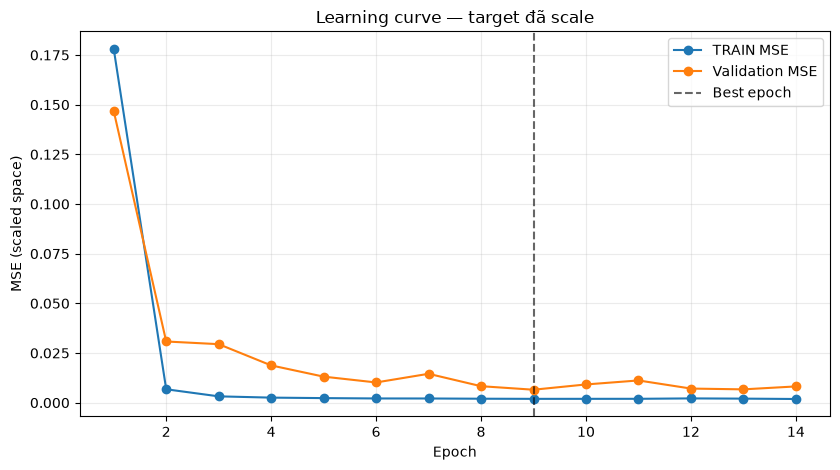

In [ ]:
epochs = np.arange(1, training_result["epochs_ran"] + 1)
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(epochs, training_result["history"]["train_loss"], marker="o", label="TRAIN MSE")
ax.plot(
    epochs,
    training_result["history"]["validation_loss"],
    marker="o",
    label="Validation MSE",
)
ax.axvline(
    training_result["best_epoch"],
    color="black",
    linestyle="--",
    alpha=0.6,
    label="Best epoch",
)
ax.set(
    title="Learning curve — target đã scale",
    xlabel="Epoch",
    ylabel="MSE (scaled space)",
)
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
loss_figure_path = FIGURE_DIR / "training_validation_loss.png"
fig.savefig(loss_figure_path, dpi=160, bbox_inches="tight")
plt.show()

## 8. Đánh giá TEST một lần và naive baseline

Sau khi validation đã chọn xong mô hình, checkpoint tốt nhất được đánh giá **một lần** trên TEST. Dự đoán RNN được inverse-transform về giá `Close` thực.

Baseline persistence dùng cùng đúng các mẫu TEST:

$$\widehat{Close}_{t+1}^{naive} = Close_t,$$

tức lấy `Close` cuối cùng trong cửa sổ 30 ngày làm dự đoán ngày kế tiếp. Baseline rất quan trọng: giá cổ phiếu thường thay đổi từng ngày ít hơn mức giá tuyệt đối, nên một mô hình có MAE nhỏ vẫn có thể kém quy tắc đơn giản này.

- **MAE:** độ lớn sai số tuyệt đối trung bình, dễ đọc theo USD.
- **RMSE:** căn của MSE, cũng theo USD nhưng nhạy hơn với sai số lớn.
- **R²:** so với dự đoán hằng bằng trung bình TEST; 1 là hoàn hảo, 0 tương đương mốc đó, và có thể âm. R² không trực tiếp so với naive baseline, vì vậy phải nhìn cả hai hàng metric.


In [ ]:
test_scaled_true, test_scaled_prediction = predict_scaled_targets(
    model, test_loader, device=DEVICE
)
test_actual = artifacts["test"]["y"].astype(np.float64)
test_prediction = inverse_transform_targets(target_scaler, test_scaled_prediction)
test_true_restored = inverse_transform_targets(target_scaler, test_scaled_true)
test_naive = artifacts["test"]["naive_last_close"].astype(np.float64)

np.testing.assert_allclose(test_true_restored, test_actual, rtol=1e-5, atol=1e-4)
rnn_metrics = regression_metrics(test_actual, test_prediction)
naive_metrics = regression_metrics(test_actual, test_naive)

metric_table = pd.DataFrame(
    [
        {
            "Mô hình": "Vanilla RNN",
            "MAE (USD)": rnn_metrics["mae"],
            "RMSE (USD)": rnn_metrics["rmse"],
            "R²": rnn_metrics["r2"],
        },
        {
            "Mô hình": "Naive: last Close",
            "MAE (USD)": naive_metrics["mae"],
            "RMSE (USD)": naive_metrics["rmse"],
            "R²": naive_metrics["r2"],
        },
    ]
).set_index("Mô hình")
metric_table.round(4)

,MAE (USD),RMSE (USD),R²
Mô hình,,,
Vanilla RNN,20.3393,23.5788,-0.0269
Naive: last Close,2.6177,3.8789,0.9722


In [ ]:
if rnn_metrics["rmse"] < naive_metrics["rmse"]:
    comparison_message = (
        "RNN có RMSE thấp hơn naive trên TEST trong lần chạy đã khóa này."
    )
elif rnn_metrics["rmse"] > naive_metrics["rmse"]:
    comparison_message = "Naive có RMSE thấp hơn RNN trên TEST; không có bằng chứng để tuyên bố RNN tốt hơn baseline."
else:
    comparison_message = (
        "RNN và naive có RMSE bằng nhau trong độ chính xác số hiện tại."
    )
print(comparison_message)

Naive có RMSE thấp hơn RNN trên TEST; không có bằng chứng để tuyên bố RNN tốt hơn baseline.


## 9. Lưu prediction và metrics có thể truy vết

CSV giữ một hàng cho mỗi ngày mục tiêu theo đúng thứ tự thời gian. JSON ghi kiến trúc, quá trình huấn luyện, metric thực trên thang giá, metric baseline, checksum đầu vào và thông tin scaling. `target_date` không bị dùng như feature.


In [ ]:
test_dates = pd.to_datetime(artifacts["test"]["target_date"].astype(str))
predictions = pd.DataFrame(
    {
        "target_date": test_dates.strftime("%Y-%m-%d"),
        "actual_close": test_actual,
        "predicted_close": test_prediction,
        "naive_close": test_naive,
    }
)
assert predictions["target_date"].is_monotonic_increasing
assert not predictions.isna().any().any()
predictions.to_csv(PREDICTIONS_PATH, index=False)

metrics_payload = {
    "task": "30 previous trading days x 5 features -> next trading day's Close",
    "framework": "PyTorch",
    "architecture": {
        "recurrent_layer": "torch.nn.RNN",
        "input_size": 5,
        "hidden_size": HIDDEN_SIZE,
        "num_layers": 1,
        "batch_first": True,
        "nonlinearity": "tanh",
        "head": "Linear(64, 1)",
    },
    "parameter_count": parameter_count,
    "seed": SEED,
    "batch_size": BATCH_SIZE,
    "optimizer": "Adam",
    "learning_rate": LEARNING_RATE,
    "loss": "MSELoss on scaled target",
    "max_epochs": MAX_EPOCHS,
    "patience": PATIENCE,
    "epochs": training_result["epochs_ran"],
    "epochs_actually_run": training_result["epochs_ran"],
    "best_epoch": training_result["best_epoch"],
    "best_validation_loss": training_result["best_validation_loss"],
    "best_validation_loss_space": "standardized target",
    "device": str(DEVICE),
    "training_duration_seconds": training_result["training_duration_seconds"],
    "MAE": rnn_metrics["mae"],
    "RMSE": rnn_metrics["rmse"],
    "R2": rnn_metrics["r2"],
    "naive_MAE": naive_metrics["mae"],
    "naive_RMSE": naive_metrics["rmse"],
    "naive_R2": naive_metrics["r2"],
    "test_metrics_real_scale": rnn_metrics,
    "naive_test_metrics_real_scale": naive_metrics,
    "real_scale_units": {"mae": "USD", "rmse": "USD", "r2": "unitless"},
    "test_evaluation_count": 1,
    "test_samples": len(predictions),
    "target_date_range": {
        "min": predictions["target_date"].iloc[0],
        "max": predictions["target_date"].iloc[-1],
    },
    "target_scaling": {
        "type": type(target_scaler).__name__,
        "fit_scope": target_scaler_info["fit_scope"],
        "path": target_scaler_info["path"],
        "sha256": target_scaler_info["sha256"],
        "inverse_transformed_for_final_metrics": True,
    },
    "input_artifact_sha256": artifact_hashes,
    "checkpoint": str(CHECKPOINT_PATH.relative_to(ROOT)).replace("\\", "/"),
    "predictions": str(PREDICTIONS_PATH.relative_to(ROOT)).replace("\\", "/"),
    "comparison": comparison_message,
}
METRICS_PATH.write_text(
    json.dumps(metrics_payload, ensure_ascii=False, indent=2), encoding="utf-8"
)

print(
    f"Đã lưu {len(predictions):,} predictions -> {PREDICTIONS_PATH.relative_to(ROOT)}"
)
print(f"Đã lưu metrics -> {METRICS_PATH.relative_to(ROOT)}")
predictions.head()

Đã lưu 410 predictions -> results\predictions\pytorch_stock_predictions.csv
Đã lưu metrics -> results\metrics\pytorch_stock_metrics.json


,target_date,actual_close,predicted_close,naive_close
0,2024-05-14,187.429993,182.216207,186.279999
1,2024-05-15,189.720001,183.601980,187.429993
2,2024-05-16,189.839996,184.804914,189.720001
3,2024-05-17,189.869995,185.953275,189.839996
4,2024-05-20,191.039993,186.191855,189.869995


## 10. Actual và predicted theo thời gian

Đồ thị nối các ngày TEST theo thứ tự thực, không xáo trộn trục thời gian. Cả RNN và naive đều được đặt cạnh giá thật trên cùng thang USD; biểu đồ chỉ mô tả kết quả ngoài mẫu của khoảng TEST đã khóa.


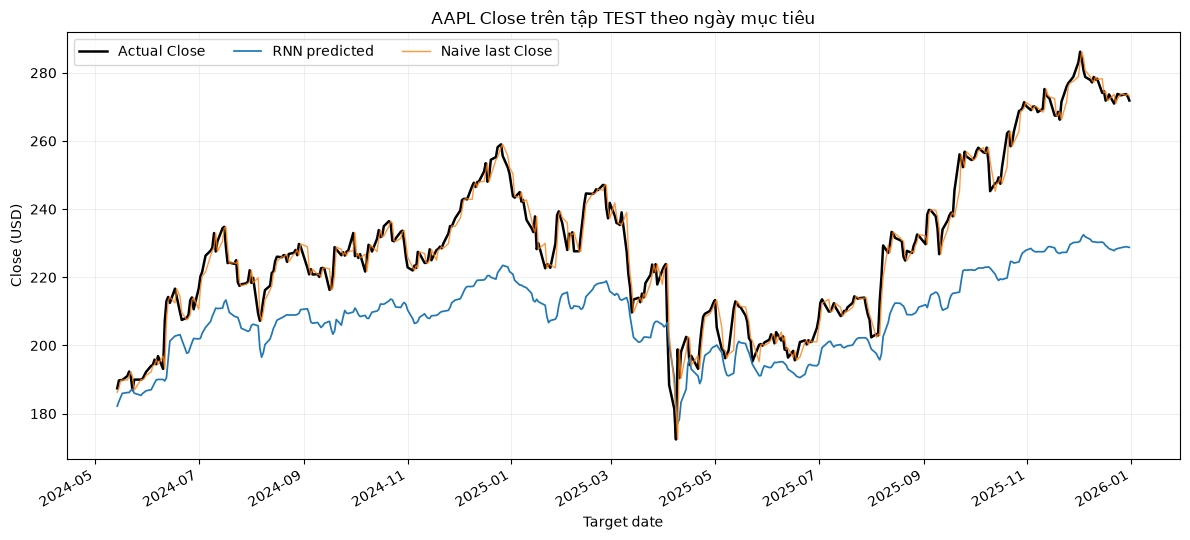

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(test_dates, test_actual, color="black", linewidth=1.8, label="Actual Close")
ax.plot(
    test_dates, test_prediction, color="#1f77b4", linewidth=1.25, label="RNN predicted"
)
ax.plot(
    test_dates,
    test_naive,
    color="#ff7f0e",
    linewidth=1.0,
    alpha=0.8,
    label="Naive last Close",
)
ax.set(
    title="AAPL Close trên tập TEST theo ngày mục tiêu",
    xlabel="Target date",
    ylabel="Close (USD)",
)
ax.grid(alpha=0.2)
ax.legend(ncol=3)
fig.autofmt_xdate()
fig.tight_layout()
prediction_figure_path = FIGURE_DIR / "test_actual_vs_predicted.png"
fig.savefig(prediction_figure_path, dpi=160, bbox_inches="tight")
plt.show()

## 11. So sánh RNN với baseline

MAE và RMSE có cùng đơn vị USD nên có thể so sánh trực tiếp. R² được tách sang panel riêng vì không có đơn vị và có thang đo khác. Chiều cao cột chỉ phản ánh TEST đã khóa, không chứng minh khả năng sinh lời hay dự báo cho giai đoạn tương lai khác.


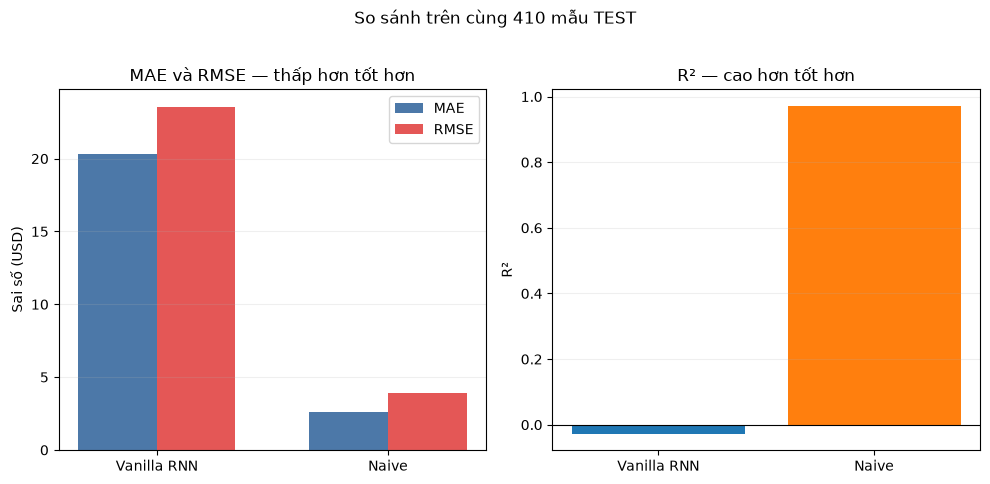

In [ ]:
labels = ["Vanilla RNN", "Naive"]
colors = ["#1f77b4", "#ff7f0e"]
fig, axes = plt.subplots(1, 2, figsize=(10, 4.7))

x = np.arange(2)
width = 0.34
axes[0].bar(
    x - width / 2,
    [rnn_metrics["mae"], naive_metrics["mae"]],
    width,
    label="MAE",
    color="#4c78a8",
)
axes[0].bar(
    x + width / 2,
    [rnn_metrics["rmse"], naive_metrics["rmse"]],
    width,
    label="RMSE",
    color="#e45756",
)
axes[0].set_xticks(x, labels)
axes[0].set_ylabel("Sai số (USD)")
axes[0].set_title("MAE và RMSE — thấp hơn tốt hơn")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.2)

axes[1].bar(labels, [rnn_metrics["r2"], naive_metrics["r2"]], color=colors)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylabel("R²")
axes[1].set_title("R² — cao hơn tốt hơn")
axes[1].grid(axis="y", alpha=0.2)

fig.suptitle("So sánh trên cùng 410 mẫu TEST", y=1.02)
fig.tight_layout()
comparison_figure_path = FIGURE_DIR / "rnn_vs_naive_metrics.png"
fig.savefig(comparison_figure_path, dpi=160, bbox_inches="tight")
plt.show()

## 12. Kiểm tra artifact đầu ra

Kiểm tra cuối xác nhận checkpoint tồn tại, CSV có đúng schema và ngày tăng nghiêm ngặt, JSON có đủ metric bắt buộc, hình đã được ghi, và ba NPZ đầu vào vẫn giữ nguyên checksum. Đây là lớp kiểm tra chống output thiếu hoặc vô tình thay đổi dữ liệu dùng chung.


In [ ]:
expected_columns = ["target_date", "actual_close", "predicted_close", "naive_close"]
assert CHECKPOINT_PATH.is_file()
assert METRICS_PATH.is_file()
assert PREDICTIONS_PATH.is_file()
assert predictions.columns.tolist() == expected_columns
assert len(predictions) == len(artifacts["test"]["y"]) == 410
assert pd.to_datetime(predictions["target_date"]).is_monotonic_increasing
assert all(
    path.is_file()
    for path in (loss_figure_path, prediction_figure_path, comparison_figure_path)
)

saved_metrics = json.loads(METRICS_PATH.read_text(encoding="utf-8"))
for key in ("MAE", "RMSE", "R2", "naive_MAE", "naive_RMSE", "naive_R2"):
    assert np.isfinite(saved_metrics[key])
for split, expected_hash in artifact_hashes.items():
    input_path = ROOT / stock_meta["artifacts"][split]["path"]
    assert sha256(input_path) == expected_hash

print("PASS — notebook chạy đầy đủ, output hợp lệ, input artifact không đổi.")
print("Figures:", sorted(path.name for path in FIGURE_DIR.glob("*.png")))

PASS — notebook chạy đầy đủ, output hợp lệ, input artifact không đổi.
Figures: ['rnn_vs_naive_metrics.png', 'test_actual_vs_predicted.png', 'training_validation_loss.png']


## 13. Kết luận và giới hạn

- Bài toán là regression: 30 ngày × 5 đặc trưng → một `Close` liên tục của ngày kế tiếp.
- Vanilla RNN dùng hidden state cuối để tóm tắt chuỗi; `Linear(64, 1)` tạo dự đoán.
- MSE huấn luyện nằm trong không gian đã scale; MAE/RMSE cuối cùng chỉ được tính sau inverse scaling về USD.
- Validation loss quyết định checkpoint và thời điểm dừng; TEST không tham gia lựa chọn mô hình.
- Naive last-Close là mốc bắt buộc. Kết luận RNN tốt hơn hay kém hơn phải dựa vào bảng metric thực, không dựa vào độ phức tạp của mô hình.
- Giá cổ phiếu chịu tác động của tin tức, kỳ vọng, thanh khoản và thay đổi chế độ thị trường mà năm biến OHLCV quá khứ không thể mô tả đầy đủ. Một split lịch sử đơn lẻ cũng không bảo đảm kết quả sẽ lặp lại trong tương lai.

Notebook này chỉ là baseline học thuật cho A06 và **không đưa ra khuyến nghị đầu tư**.
